# Case 1: Maximize Sharpe ratio

## Data load

In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import tensorflow as tf
from sklearn.model_selection import train_test_split

import data_management as dm
from portfolios import Portfolio, Portfolio_Collection
from models import MPOModel
import risk_measures as rm
from utils import sparsemax

import warnings

warnings.filterwarnings("ignore")
tf.keras.backend.set_floatx("float32")
np.set_default_dtype = np.float32

### Index and components

In [2]:
data, data_idx = dm.DataManagement.get_data(
    asset_price_path="../data/data_comp_SP500.csv",
    idx_price_path="../data/data_idx_SP500.csv",
)

### Train/Test split

In [ ]:
# Desired dates.
ds_start_date = "2010-07-15"
ds_end_date = "2024-10-18"

# Simmulations.
n_sims = 100
simmulation_datasets = {}
rng = np.random.default_rng(seed=42)
for s in range(n_sims):
    # For each simulation, we will create a new dataset.
    # Random selection of number of assets between 10 and maximum.
    # Random selection of assets.
    # Different temporal windows.

    # Number of assets.
    min_n_assets = 10
    max_n_assets = data.shape[1]
    n_assets = rng.integers(min_n_assets, max_n_assets + 1)

    # Randomly select assets.
    selected_assets = rng.choice(data.columns, n_assets, replace=False)

    # Dataset for the simulation.
    data_sim = data[selected_assets].copy()

    # Sync dataframes
    data_sim, data_idx = dm.DataManagement.sync_dataframes(data_sim, data_idx)

    # Randomly select start and end dates for the simulation.
    start_date = rng.choice(
        pd.date_range(pd.to_datetime(ds_start_date), pd.to_datetime(ds_start_date) + pd.DateOffset(years=5), freq="D")
    )
    end_date = rng.choice(
        pd.date_range(pd.to_datetime(ds_end_date) - pd.DateOffset(years=5), pd.to_datetime(ds_end_date), freq="D")
    )

    # Split the data into training and testing sets.
    train_data, test_data, train_idx, test_idx = train_test_split(
        data_sim.loc[start_date:end_date],
        data_idx.loc[start_date:end_date],
        test_size=0.2,
        shuffle=False,
        random_state=42,
    )

    # Compute logarithmic returns.
    train_data_log_ret = dm.DataManagement.convert_prices_to_log_returns(train_data)
    train_idx_log_ret = dm.DataManagement.convert_prices_to_log_returns(train_idx)
    test_data_log_ret = dm.DataManagement.convert_prices_to_log_returns(test_data)
    test_idx_log_ret = dm.DataManagement.convert_prices_to_log_returns(test_idx)

    # Add the dataset to the dictionary.
    simmulation_datasets[s] = {
        "train_data": train_data_log_ret,
        "train_idx": train_idx_log_ret,
        "test_data": test_data_log_ret,
        "test_idx": test_idx_log_ret,
        "start_date": start_date,
        "end_date": end_date,
    }

In [ ]:
train_data.shape, test_data.shape, train_idx.shape, test_idx.shape

((1688, 104), (423, 104), (1688, 1), (423, 1))

In [5]:
risk_free_return = np.float32(0.08 / 252)
# risk_free_return = 0.0

## Portfolio optimization using CVXPY

In [ ]:
def calculate_optimal_weights_maximize_sharpe(data: pd.DataFrame, rf: float = 0.0, verbose=True) -> tuple:
    """Calculates the optimal portfolio weights using CVXPY by maximizing Sharpe ratio.
    Args:
        data (pd.DataFrame): Asset returns.
        rf (float, optional): Risk-free rate. Defaults to 0.0.
    Returns:
        tuple: Asset names, optimal weights, Sharpe ratio
    """
    # Asset returns.
    asset_returns = data  # (num_days, num_assets)

    # Number of assets.
    n_assets = asset_returns.shape[1]

    # Define the optimization problem variables.
    w = cp.Variable(n_assets)  # (num_assets,) -> Portfolio asset weights.

    # Expected returns of the assets.
    mu = asset_returns.mean().to_numpy()  # (num_assets,)

    # Covariance matrix of portfolio returns.
    Q = asset_returns.cov().to_numpy()  # (num_assets, num_assets)

    # Adjust the return vector.
    mu_hat = mu - rf  # (num_assets,)

    constraints = [
        mu_hat @ w == 1,  # Sharpe numerator equals 1
        w >= 0,  # Long-only positions
    ]

    # Define the objective function to minimize.
    objective = cp.Minimize(cp.quad_form(w, Q))  # w.T @ Q @ w

    # Define the optimization problem.
    problem = cp.Problem(objective, constraints)

    # Solve the optimization problem.
    # problem.solve(solver=cp.XPRESS, verbose=False)
    problem.solve(verbose=False)

    if verbose:
        print("Problem status:", problem.status)
        print("Optimal value of the objective function:", problem.value)

    # Results
    w_optimal = w.value
    w_optimal = w_optimal.astype(np.float32)

    if w_optimal is None:
        if verbose:
            print("The solver did not find an optimal solution.")
    else:
        # Normalize the weights
        optimal_weights = w_optimal / np.sum(w_optimal)

        # Sharpe ratio
        sharpe = rm.RiskMeasures.Sharpe_Ratio(asset_returns @ optimal_weights, rf)

        if verbose:
            print("Optimal portfolio weights:", optimal_weights)
            print("Sharpe ratio:", sharpe)

    return data.columns, optimal_weights, sharpe


cvxpy_sims = {}
for s in range(n_sims):
    X_train = simmulation_datasets[s]["train_data"]
    assets, opt_weights_max_sharpe, sharpe = calculate_optimal_weights_maximize_sharpe(
        X_train, rf=risk_free_return, verbose=False
    )
    cvxpy_sims[s] = {
        "assets": assets,
        "optimal_weights": opt_weights_max_sharpe,
        "sharpe": sharpe,
        "start_date": simmulation_datasets[s]["start_date"],
        "end_date": simmulation_datasets[s]["end_date"],
    }

In [7]:
cvxpy_portfolio_name = "Case 1 - CVXPY - Simulation 0"
cvxpy_portfolio = Portfolio(
    name=cvxpy_portfolio_name,
    asset_weights=cvxpy_sims[0]["optimal_weights"],
    asset_names=cvxpy_sims[0]["assets"],
)

Number of assets in portfolio: 10


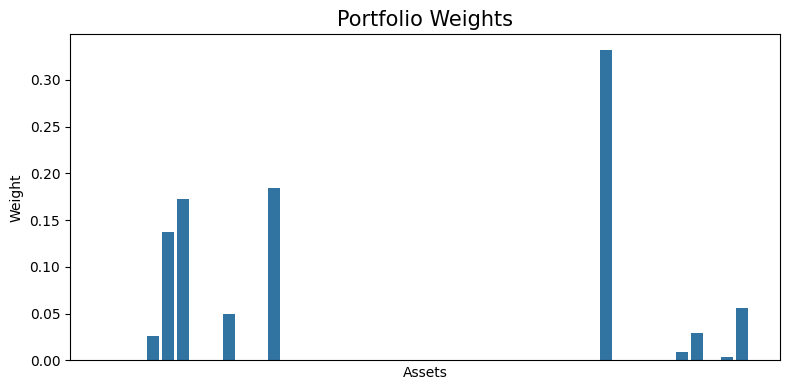

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & CBRE & AON & EXC & FSLR & NSC & RMD & DHR & TDY & ODFL & CI & NEM & BIIB & MNST & GPN & PNW & TGT & HOLX & PM & MRK & HAS & PG & GS & SCHW & REGN & WYNN & TSCO & GD & TSLA & WAB & IP & WELL & COST & ORCL & FITB & KO & MKTX & KEY & APH & CE & MAS & EW & IDXX & INCY & AVGO & AMT & STT & AVY \\
\midrule
Weight & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.025736 & 0.137367 & 0.172374 & 0.000000 & 0.000000 & 0.049570 & 0.000000 & 0.000000 & 0.184858 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.332050 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.008775 & 0.029189 & 0.000000 & 0.003386 & 0.055830 & 0.000000 & 0.000000 \\
\bottomrule
\end{tabular}



In [8]:
cvxpy_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=False,
    zero_threshold=1e-3,
    save_as="../results/Case_01/MaxSharpe_cvxpy_optimizer_portfolio_weights.png",
)

Number of assets in portfolio: 10


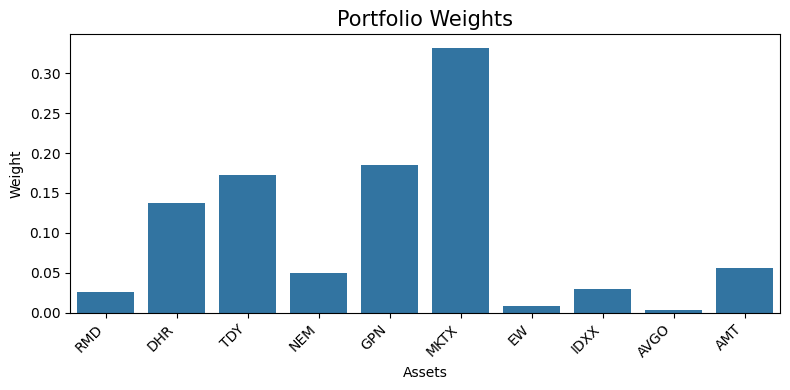

\begin{tabular}{lrrrrrrrrrr}
\toprule
 & RMD & DHR & TDY & NEM & GPN & MKTX & EW & IDXX & AVGO & AMT \\
\midrule
Weight & 0.025736 & 0.137367 & 0.172374 & 0.049570 & 0.184858 & 0.332050 & 0.008775 & 0.029189 & 0.003386 & 0.055830 \\
\bottomrule
\end{tabular}



In [9]:
cvxpy_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=True,
    save_as="../results/Case_01/MaxSharpe_cvxpy_optimizer_portfolio_weights_no_zeros.png",
)

## Portfolio optimization using gradient descent

In [10]:
def custom_loss_function(rf=0.0):
    def loss_function(
        assets_rets,  # Asset returns
        w,  # Portfolio weights
        idx=None,  # Index returns
    ):
        # Portfolio returns.
        p_rets = tf.matmul(assets_rets, w)

        ###############
        # Sharpe Ratio
        ###############
        sharpe_ratio = rm.RiskMeasures.Sharpe_Ratio_tf(x=p_rets, r_f=rf)
        penalty_sharpe = -sharpe_ratio

        # Update the loss.
        loss = penalty_sharpe

        return {
            "loss": loss,  # Only for training, without converting to numpy.
            "weights": w.numpy(),
            "metrics": {
                "loss": loss.numpy(),
                "penalty_sharpe": penalty_sharpe.numpy(),
            },
        }

    return loss_function

In [11]:
def custom_get_best_weights():
    def get_best_weights(history: list) -> np.ndarray:
        weights = pd.DataFrame([h["weights"].squeeze() for h in history])
        metrics = pd.DataFrame([h["metrics"] for h in history])
        idx_min_loss = metrics["loss"].idxmin()
        selected_weights = weights.loc[idx_min_loss].to_numpy()
        return selected_weights.squeeze()

    return get_best_weights

In [12]:
def custom_weights_function():
    return sparsemax

In [13]:
from tqdm import tqdm

mpo_sims = {}
for s in tqdm(range(n_sims)):
    # Data.
    X_train = simmulation_datasets[s]["train_data"]
    y_train = simmulation_datasets[s]["train_idx"]

    # MPOModel parameters.
    num_assets = X_train.shape[1]
    loss_function = custom_loss_function(
        rf=tf.constant(risk_free_return, dtype=tf.float32),
    )
    weights_function = custom_weights_function()
    get_best_weights_function = custom_get_best_weights()
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-2)

    # Create and fit the MPOModel.
    mpo = MPOModel(
        num_assets=num_assets,
        loss_function=loss_function,
        weights_function=weights_function,
        get_best_weights_function=get_best_weights_function,
        optimizer=optimizer,
        random_weight_init=False,
    )
    history = mpo.fit(x=X_train, idx=y_train, epochs=500)

    mpo_sims[s] = {
        "model": mpo,
        "assets": X_train.columns,
        "start_date": simmulation_datasets[s]["start_date"],
        "end_date": simmulation_datasets[s]["end_date"],
    }

100%|██████████| 100/100 [04:39<00:00,  2.80s/it]


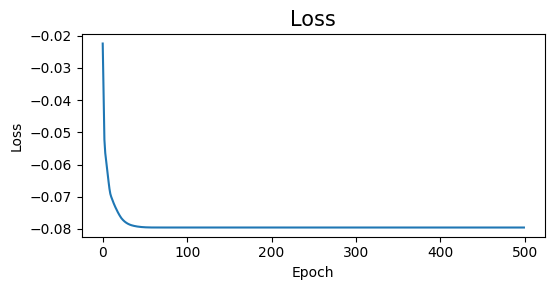

In [14]:
mpo = mpo_sims[0]["model"]
mpo.plot_all_training_metrics(
    save_as="../results/Case_01/MaxSharpe_gd_optimizer_training_metrics.png",
    titles={
        "loss": "Loss",
        "penalty_sharpe": "Sharpe Ratio",
    },
)

In [15]:
gd_portfolio_name = "Case 1 - GD - Simulation 0"
gd_portfolio = Portfolio(
    name=gd_portfolio_name,
    asset_weights=mpo.get_best_weights(),
    asset_names=mpo_sims[0]["assets"],
)

Number of assets in portfolio: 8


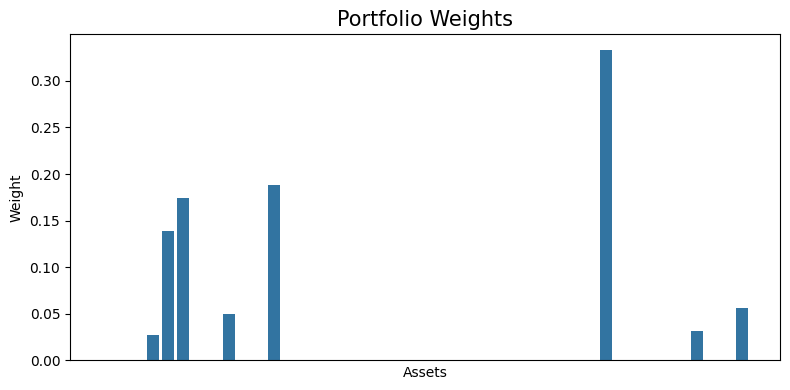

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & CBRE & AON & EXC & FSLR & NSC & RMD & DHR & TDY & ODFL & CI & NEM & BIIB & MNST & GPN & PNW & TGT & HOLX & PM & MRK & HAS & PG & GS & SCHW & REGN & WYNN & TSCO & GD & TSLA & WAB & IP & WELL & COST & ORCL & FITB & KO & MKTX & KEY & APH & CE & MAS & EW & IDXX & INCY & AVGO & AMT & STT & AVY \\
\midrule
Weight & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.027714 & 0.138672 & 0.174682 & 0.000000 & 0.000000 & 0.049797 & 0.000000 & 0.000000 & 0.188073 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.333175 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.031301 & 0.000000 & 0.000000 & 0.056586 & 0.000000 & 0.000000 \\
\bottomrule
\end{tabular}



In [16]:
gd_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=False,
    save_as="../results/Case_01/MaxSharpe_gd_optimizer_portfolio_weights.png",
)

Number of assets in portfolio: 8


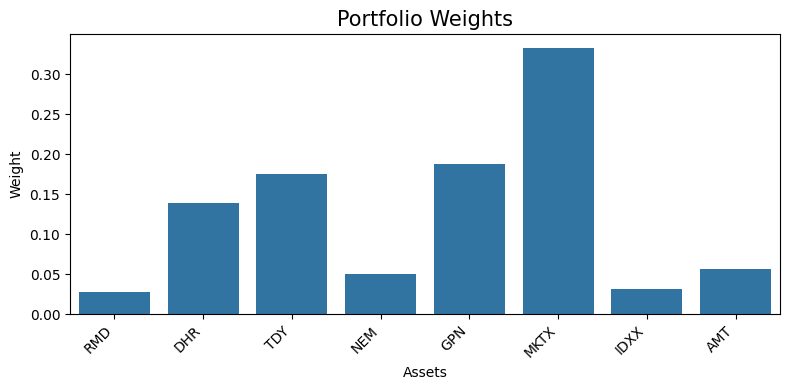

\begin{tabular}{lrrrrrrrr}
\toprule
 & RMD & DHR & TDY & NEM & GPN & MKTX & IDXX & AMT \\
\midrule
Weight & 0.027714 & 0.138672 & 0.174682 & 0.049797 & 0.188073 & 0.333175 & 0.031301 & 0.056586 \\
\bottomrule
\end{tabular}



In [17]:
gd_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=True,
    save_as="../results/Case_01/MaxSharpe_gd_optimizer_portfolio_weights_no_zeros.png",
)

## Comparison

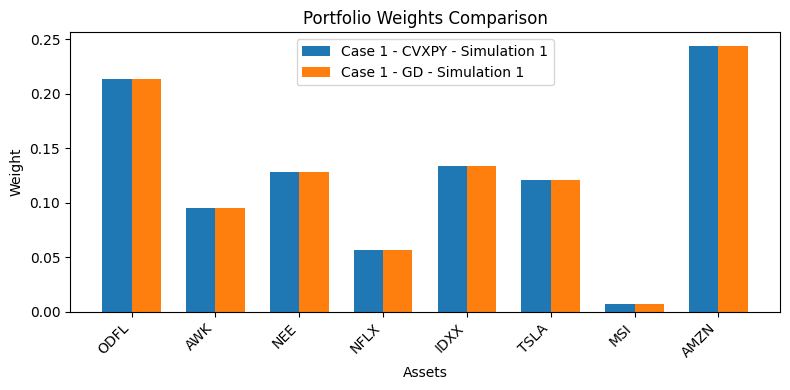

                                   ODFL       AWK       NEE      NFLX  \
Case 1 - CVXPY - Simulation 1  0.214025  0.094945  0.128513  0.056490   
Case 1 - GD - Simulation 1     0.214007  0.094955  0.128515  0.056515   

                                   IDXX      TSLA       MSI      AMZN  
Case 1 - CVXPY - Simulation 1  0.133947  0.121211  0.006601  0.244268  
Case 1 - GD - Simulation 1     0.133940  0.121210  0.006641  0.244218  


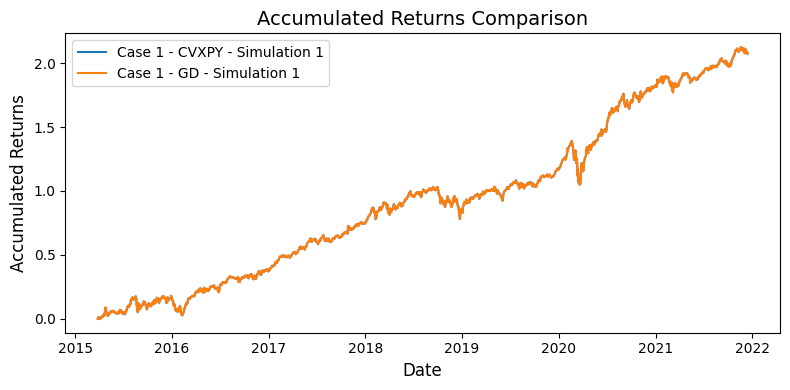

                                    Std    Sharpe  TrackingError       VaR  \
Case 1 - CVXPY - Simulation 1  0.013179  0.068987       0.007554  0.020362   
Case 1 - GD - Simulation 1     0.013179  0.068987       0.007553  0.020361   

                                   CVaR  WeightsOver10pct  WeightsOver5pct  
Case 1 - CVXPY - Simulation 1  0.031871          0.341964         0.993399  
Case 1 - GD - Simulation 1     0.031870          0.341890         0.993360  
************************
Start date: 2015-03-26T00:00:00.000000000
End date: 2023-08-23T00:00:00.000000000


In [ ]:
n_sim = 1

# Allows us to store and compare the different portfolios.
portfolios = Portfolio_Collection(portfolio_names=[], portfolio_weights=[], asset_names=mpo_sims[n_sim]["assets"])

# CVXPY Portfolio.
cvxpy_portfolio_name = f"Case 1 - CVXPY - Simulation {n_sim}"
cvxpy_portfolio = Portfolio(
    name=cvxpy_portfolio_name,
    asset_weights=cvxpy_sims[n_sim]["optimal_weights"],
    asset_names=cvxpy_sims[n_sim]["assets"],
)
portfolios.replace_or_add_portfolio(name=cvxpy_portfolio.name, new_portfolio=cvxpy_portfolio)

# GD Portfolio.
mpo = mpo_sims[n_sim]["model"]
gd_portfolio_name = f"Case 1 - GD - Simulation {n_sim}"
gd_portfolio = Portfolio(
    name=gd_portfolio_name,
    asset_weights=mpo.get_best_weights(),
    asset_names=mpo_sims[n_sim]["assets"],
)
portfolios.replace_or_add_portfolio(name=gd_portfolio.name, new_portfolio=gd_portfolio)

# Plotting the comparison of the two portfolios.
portfolios.plot_weight_comparison(
    portfolio_names=[
        cvxpy_portfolio.name,
        gd_portfolio.name,
    ],
    plot_ucits_limits=False,
    skip_zero_weights=True,
    zero_threshold=1e-3,
    save_as="../results/Case_01/MaxSharpe_portfolio_weights_comparison.png",
)

portfolios.plot_cumulative_returns(
    asset_returns=simmulation_datasets[n_sim]["train_data"],
    idx_returns=simmulation_datasets[n_sim]["train_idx"],
    portfolio_names=[
        cvxpy_portfolio.name,
        gd_portfolio.name,
    ],
    plot_idx=False,
    comparable_returns=[],
    rf=risk_free_return,
    zero_start=True,
    save_as="../results/Case_01/MaxSharpe_portfolio_acum_returns_comparison.png",
    figsize=(8, 4),
)

print("************************")
print(f"Start date: {simmulation_datasets[n_sim]['start_date']}")
print(f"End date: {simmulation_datasets[n_sim]['end_date']}")

MSE of weight vectors

In [19]:
errors = []
for k in cvxpy_sims.keys():
    u = cvxpy_sims[k]["optimal_weights"]
    v = mpo_sims[k]["model"].get_best_weights()
    squared_error = np.sum((u - v) ** 2)
    errors.append(squared_error)
mse = np.mean(errors)
print(f"Mean Squared Error between CVXPY and GD portfolios: {mse}")

Mean Squared Error between CVXPY and GD portfolios: 3.617891707108356e-05
